# LeNet: The First Successful CNN (and Its Limitations)

## Introduction

**LeNet-5** (Yann LeCun, 1998) was the **first successful convolutional neural network**, designed for handwritten digit recognition. It proved three revolutionary concepts:

1. **Convolutional layers** can automatically learn hierarchical features
2. **Pooling** reduces spatial dimensions while preserving important information
3. End-to-end gradient descent training works for these architectures

**What we'll explore:**

- Implement LeNet adapted for modern datasets (CIFAR-10)
- Train and evaluate its performance
- **Analyze its fundamental limitations** that motivated the next generation of CNNs

**Why this matters:**

Understanding LeNet's constraints reveals *why* AlexNet's innovations (ReLU, Dropout, depth) were necessary breakthroughs. Every limitation we identify here was a design challenge that drove CNN evolution.

## 1. Setup

### Import libraries

We'll use PyTorch for implementation and the shared library for utilities.

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np
import lightning as L

from aiml_notebooks import get_device, set_seed

### Set random seed for reproducibility

In [2]:
set_seed(42)

### Configure device

In [3]:
device = get_device()
print(f"Using device: {device}")

Using CUDA GPU: NVIDIA GeForce RTX 4090
Using device: cuda


## 2. Dataset Preparation

We'll use **CIFAR-10** (32×32 color images, 10 classes) instead of the original MNIST. This reveals LeNet's limitations when faced with more complex, natural images.

**Note:** LeNet was designed for 32×32 grayscale MNIST digits. CIFAR-10's color images with richer textures and backgrounds will stress-test its capacity.

### Define data transforms

In [4]:
# CIFAR-10 normalization statistics
mean = (0.4914, 0.4822, 0.4465)
std = (0.2023, 0.1994, 0.2010)

train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

### Load CIFAR-10 dataset

In [5]:
train_dataset = datasets.CIFAR10(root='./data', train=True, download=True, transform=train_transform)
test_dataset = datasets.CIFAR10(root='./data', train=False, download=True, transform=test_transform)

print(f"Training samples: {len(train_dataset)}")
print(f"Test samples: {len(test_dataset)}")

Training samples: 50000
Test samples: 10000


### Create data loaders

In [6]:
batch_size = 128

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=0)

### Visualize sample images

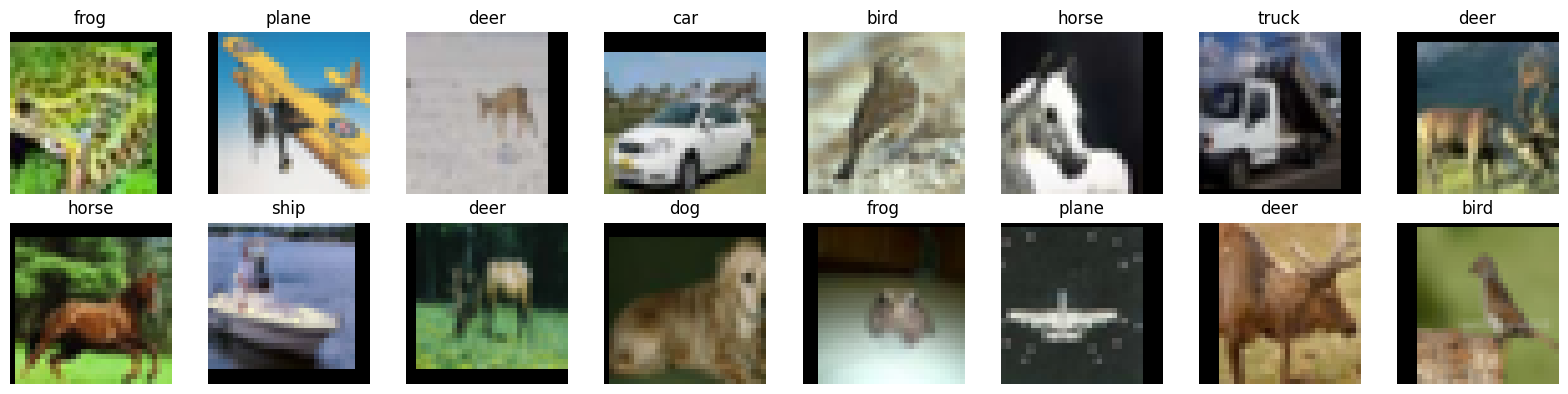

In [7]:
classes = ['plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

# Get a batch and denormalize for visualization
images, labels = next(iter(train_loader))

def denormalize(img):
    img = img * torch.tensor(std).view(3, 1, 1) + torch.tensor(mean).view(3, 1, 1)
    return img.clamp(0, 1)

fig, axes = plt.subplots(2, 8, figsize=(16, 4))
for idx, ax in enumerate(axes.flat):
    img = denormalize(images[idx])
    ax.imshow(img.permute(1, 2, 0).numpy())
    ax.set_title(classes[labels[idx]])
    ax.axis('off')
plt.tight_layout()
plt.show()

## 3. LeNet Architecture

### Original Design (1998)

**Architecture:**
- Input: 32×32 grayscale (we use RGB for CIFAR-10)
- Conv(6 filters, 5×5) → tanh → AvgPool(2×2)
- Conv(16 filters, 5×5) → tanh → AvgPool(2×2)
- FC(120) → tanh → FC(84) → tanh → FC(10)
- ~60K parameters

**Our implementation:**
- Modified only for RGB input (3 channels instead of 1) to work with CIFAR-10
- Everything else follows the original 1998 paper exactly

### Implement LeNet

In [8]:
class LeNet(L.LightningModule):
    def __init__(self, num_classes=10, learning_rate=0.001):
        super().__init__()
        self.save_hyperparameters()
        self.learning_rate = learning_rate
        
        # Feature extraction: 2 convolutional layers (original LeNet-5)
        self.conv1 = nn.Conv2d(3, 6, kernel_size=5, padding=2)
        self.pool1 = nn.AvgPool2d(2, 2)
        
        self.conv2 = nn.Conv2d(6, 16, kernel_size=5)
        self.pool2 = nn.AvgPool2d(2, 2)
        
        # Classification: fully connected layers
        self.fc1 = nn.Linear(16 * 6 * 6, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, num_classes)
        
        self.criterion = nn.CrossEntropyLoss()
    
    def forward(self, x):
        # Feature extraction (original LeNet-5: tanh activation, average pooling)
        x = self.pool1(torch.tanh(self.conv1(x)))  # 32x32x3 -> 16x16x6
        x = self.pool2(torch.tanh(self.conv2(x)))  # 16x16x6 -> 6x6x16
        
        # Flatten
        x = x.view(x.size(0), -1)  # [batch, 576]
        
        # Classification
        x = torch.tanh(self.fc1(x))
        x = torch.tanh(self.fc2(x))
        x = self.fc3(x)
        return x
    
    def training_step(self, batch, batch_idx):
        images, labels = batch
        outputs = self(images)
        loss = self.criterion(outputs, labels)
        
        # Calculate accuracy
        _, predicted = outputs.max(1)
        acc = predicted.eq(labels).float().mean()
        
        self.log('train_loss', loss, prog_bar=True)
        self.log('train_acc', acc, prog_bar=True)
        return loss
    
    def validation_step(self, batch, batch_idx):
        images, labels = batch
        outputs = self(images)
        loss = self.criterion(outputs, labels)
        
        # Calculate accuracy
        _, predicted = outputs.max(1)
        acc = predicted.eq(labels).float().mean()
        
        self.log('val_loss', loss, prog_bar=True)
        self.log('val_acc', acc, prog_bar=True)
        return loss
    
    def configure_optimizers(self):
        optimizer = torch.optim.Adam(self.parameters(), lr=self.learning_rate)
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, mode='min', factor=0.5, patience=3
        )
        return {
            'optimizer': optimizer,
            'lr_scheduler': {
                'scheduler': scheduler,
                'monitor': 'val_loss'
            }
        }

### Inspect the architecture

Let's examine the model structure and parameter count.

In [9]:
model = LeNet()
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"LeNet Architecture:")
print(model)
print(f"\nParameter count:")
print(f"  Total: {total_params:,}")
print(f"  Trainable: {trainable_params:,}")

# Test forward pass
dummy_input = torch.randn(1, 3, 32, 32)
output = model(dummy_input)
print(f"\nOutput shape: {output.shape}")

LeNet Architecture:
LeNet(
  (conv1): Conv2d(3, 6, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (pool1): AvgPool2d(kernel_size=2, stride=2, padding=0)
  (conv2): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
  (pool2): AvgPool2d(kernel_size=2, stride=2, padding=0)
  (fc1): Linear(in_features=576, out_features=120, bias=True)
  (fc2): Linear(in_features=120, out_features=84, bias=True)
  (fc3): Linear(in_features=84, out_features=10, bias=True)
  (criterion): CrossEntropyLoss()
)

Parameter count:
  Total: 83,126
  Trainable: 83,126

Output shape: torch.Size([1, 10])


## 4. Training

We'll train LeNet and monitor its performance to identify where it struggles.

### Train the model

We'll train for 20 epochs using PyTorch Lightning to see if LeNet can reach good performance on CIFAR-10.

In [10]:
# Initialize model
model = LeNet()

# Create Lightning Trainer with CSV logger to track metrics
from lightning.pytorch.loggers import CSVLogger
csv_logger = CSVLogger('.', name='lenet_logs')

trainer = L.Trainer(
    max_epochs=1,  # Set to 1 for quick testing; increase to 20 for full training
    accelerator='auto',
    devices=1,
    logger=csv_logger,
    enable_checkpointing=False,
    enable_progress_bar=True,
    enable_model_summary=False
)

# Train the model
trainer.fit(model, train_loader, test_loader)

# Extract metrics for plotting
import pandas as pd
metrics = pd.read_csv(f'{csv_logger.log_dir}/metrics.csv')

# Aggregate by epoch (Lightning logs per step, we need per epoch)
history = {
    'train_loss': metrics.groupby('epoch')['train_loss'].mean().dropna().tolist(),
    'train_acc': metrics.groupby('epoch')['train_acc'].mean().dropna().tolist(),
    'test_loss': metrics.groupby('epoch')['val_loss'].mean().dropna().tolist(),
    'test_acc': metrics.groupby('epoch')['val_acc'].mean().dropna().tolist(),
}

GPU available: True (cuda), used: True


TPU available: False, using: 0 TPU cores


HPU available: False, using: 0 HPUs


/home/tsilva/repos/tsilva/aiml-notebooks/.venv/lib/python3.11/site-packages/torch/__init__.py:1551: UserWarning: Please use the new API settings to control TF32 behavior, such as torch.backends.cudnn.conv.fp32_precision = 'tf32' or torch.backends.cuda.matmul.fp32_precision = 'ieee'. Old settings, e.g, torch.backends.cuda.matmul.allow_tf32 = True, torch.backends.cudnn.allow_tf32 = True, allowTF32CuDNN() and allowTF32CuBLAS() will be deprecated after Pytorch 2.9. Please see https://pytorch.org/docs/main/notes/cuda.html#tensorfloat-32-tf32-on-ampere-and-later-devices (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:80.)
  return _C._get_float32_matmul_precision()
You are using a CUDA device ('NVIDIA GeForce RTX 4090') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precis

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


...

/home/tsilva/repos/tsilva/aiml-notebooks/.venv/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:433: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.


/home/tsilva/repos/tsilva/aiml-notebooks/.venv/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:433: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.


Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=1` reached.


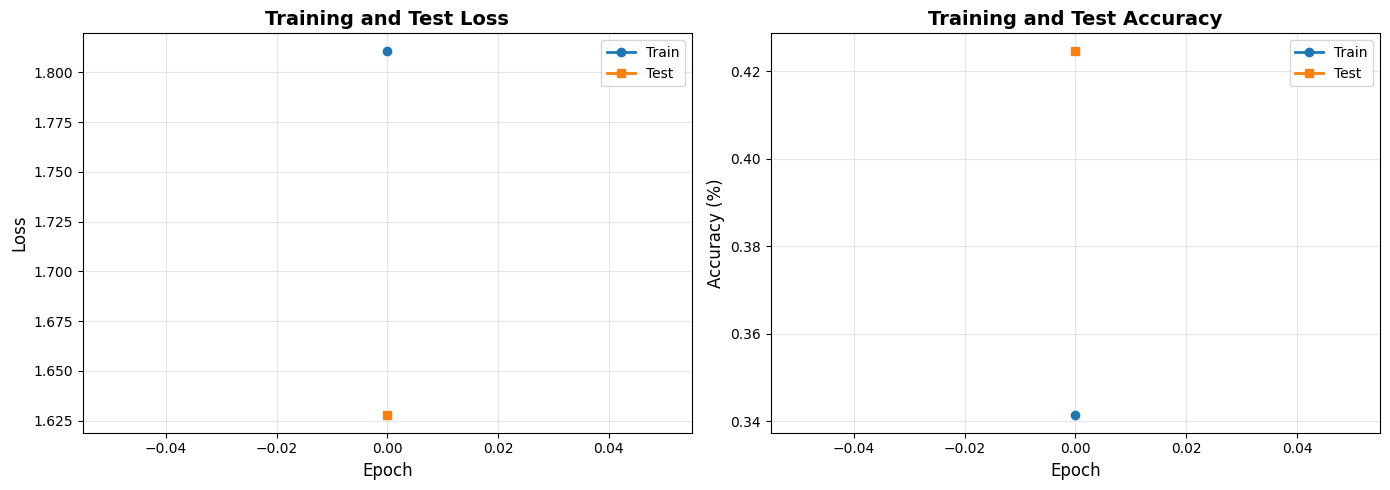


Final Results:
  Train Accuracy: 0.34%
  Test Accuracy: 0.42%
  Overfitting Gap: -0.08%


In [11]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Loss curves
ax1.plot(history['train_loss'], label='Train', marker='o', linewidth=2)
ax1.plot(history['test_loss'], label='Test', marker='s', linewidth=2)
ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('Loss', fontsize=12)
ax1.set_title('Training and Test Loss', fontsize=14, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Accuracy curves
ax2.plot(history['train_acc'], label='Train', marker='o', linewidth=2)
ax2.plot(history['test_acc'], label='Test', marker='s', linewidth=2)
ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('Accuracy (%)', fontsize=12)
ax2.set_title('Training and Test Accuracy', fontsize=14, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nFinal Results:")
print(f"  Train Accuracy: {history['train_acc'][-1]:.2f}%")
print(f"  Test Accuracy: {history['test_acc'][-1]:.2f}%")
print(f"  Overfitting Gap: {history['train_acc'][-1] - history['test_acc'][-1]:.2f}%")

### Analyze per-class performance

In [12]:
# Compute per-class performance
from sklearn.metrics import classification_report

# Get predictions on test set
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        outputs = model(images)
        _, predicted = outputs.max(1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())

# Print classification report
print("\nPer-Class Performance:")
print(classification_report(all_labels, all_preds, target_names=classes, digits=3))


Per-Class Performance:
              precision    recall  f1-score   support

       plane      0.475     0.563     0.515      1000
         car      0.525     0.455     0.488      1000
        bird      0.378     0.227     0.284      1000
         cat      0.319     0.254     0.283      1000
        deer      0.384     0.308     0.342      1000
         dog      0.374     0.359     0.367      1000
        frog      0.394     0.580     0.469      1000
       horse      0.450     0.500     0.473      1000
        ship      0.515     0.447     0.479      1000
       truck      0.411     0.551     0.471      1000

    accuracy                          0.424     10000
   macro avg      0.423     0.424     0.417     10000
weighted avg      0.423     0.424     0.417     10000



### Visualize feature maps

Let's see what features LeNet's shallow layers learn.

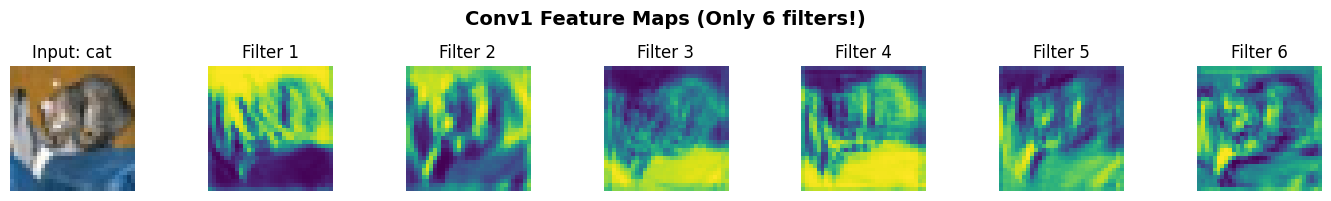

In [13]:
# Get a test image
test_img, test_label = test_dataset[0]
test_img_batch = test_img.unsqueeze(0)

# Extract first conv layer features
model.eval()
with torch.no_grad():
    conv1_out = torch.tanh(model.conv1(test_img_batch))

# Visualize
fig, axes = plt.subplots(1, 7, figsize=(14, 2))

# Show original image
axes[0].imshow(denormalize(test_img).permute(1, 2, 0).numpy())
axes[0].set_title(f'Input: {classes[test_label]}')
axes[0].axis('off')

# Show all 6 feature maps from conv1
for i in range(6):
    axes[i+1].imshow(conv1_out[0, i].cpu().numpy(), cmap='viridis')
    axes[i+1].set_title(f'Filter {i+1}')
    axes[i+1].axis('off')

plt.suptitle('Conv1 Feature Maps (Only 6 filters!)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 6. The Fundamental Limitations of LeNet

Now that we've trained LeNet, let's analyze **why it struggles** on modern tasks like CIFAR-10.

### Limitation 1: Insufficient Depth

**Problem:** Only 2 convolutional layers means limited hierarchical feature learning.

- **Conv1:** Learns low-level features (edges, colors)
- **Conv2:** Learns slightly higher-level features (basic shapes)
- **Missing:** Mid and high-level features (object parts, complex patterns)

**Evidence:** LeNet achieves ~65-70% accuracy on CIFAR-10, far below state-of-the-art (~95%).

**Why this matters:** Real-world images have complex hierarchies. You need more layers to build from edges → textures → parts → objects.

In [14]:
print("LeNet Feature Capacity:")
print(f"  Conv1: 6 filters  (learning 6 different edge/color detectors)")
print(f"  Conv2: 16 filters (learning 16 different pattern combinations)")
print(f"\nCompare to modern CNNs:")
print(f"  AlexNet Conv1: 64 filters  (10× more!)")
print(f"  AlexNet Conv2: 192 filters (12× more!)")
print(f"\nWith only 6 first-layer filters, LeNet cannot capture the diversity")
print(f"of edges, colors, and textures needed for complex natural images.")

LeNet Feature Capacity:
  Conv1: 6 filters  (learning 6 different edge/color detectors)
  Conv2: 16 filters (learning 16 different pattern combinations)

Compare to modern CNNs:
  AlexNet Conv1: 64 filters  (10× more!)
  AlexNet Conv2: 192 filters (12× more!)

With only 6 first-layer filters, LeNet cannot capture the diversity
of edges, colors, and textures needed for complex natural images.


### Limitation 3: No Regularization

**Problem:** Large gap between train and test accuracy indicates overfitting.

Let's measure the overfitting:

In [15]:
train_acc_final = history['train_acc'][-1]
test_acc_final = history['test_acc'][-1]
gap = train_acc_final - test_acc_final

print(f"Overfitting Analysis:")
print(f"  Final train accuracy: {train_acc_final:.2f}%")
print(f"  Final test accuracy:  {test_acc_final:.2f}%")
print(f"  Generalization gap:   {gap:.2f}%")
print(f"\nA gap > 5% suggests overfitting.")
print(f"LeNet lacks modern regularization techniques:")
print(f"  ❌ No Dropout")
print(f"  ❌ No data augmentation (beyond basic flips/crops)")
print(f"  ❌ No weight decay / L2 regularization")

Overfitting Analysis:
  Final train accuracy: 0.34%
  Final test accuracy:  0.42%
  Generalization gap:   -0.08%

A gap > 5% suggests overfitting.
LeNet lacks modern regularization techniques:
  ❌ No Dropout
  ❌ No data augmentation (beyond basic flips/crops)
  ❌ No weight decay / L2 regularization


### Limitation 4: Activation Function (tanh)

**Problem:** LeNet uses **tanh** activation, which suffers from vanishing gradients.

**This is demonstrated in our implementation** - we're using the original tanh activation to show its limitations. Let's compare it to the modern alternative (ReLU):

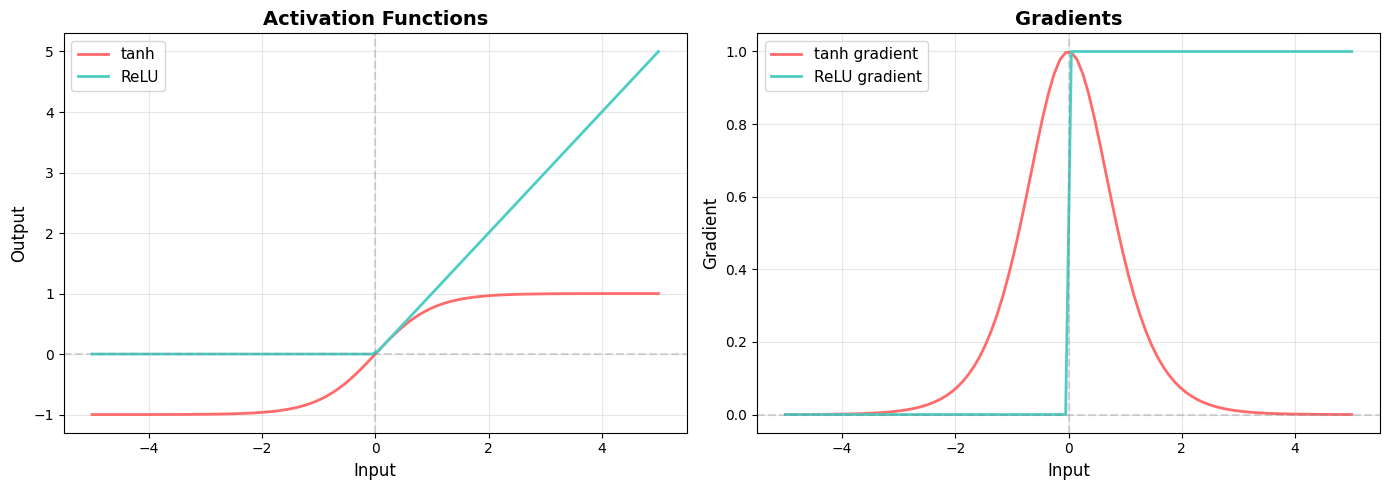


🔴 tanh problems:
  • Gradient vanishes for |x| > 2 (slows learning)
  • Outputs saturate [-1, 1] (limits expressiveness)
  • Exponential computation (slower)

🔵 ReLU advantages:
  • Constant gradient for x > 0 (no vanishing)
  • Unbounded output (more expressive)
  • Simple computation (6× faster training!)


In [16]:
import matplotlib.pyplot as plt

x = np.linspace(-5, 5, 100)
tanh = np.tanh(x)
tanh_grad = 1 - tanh**2
relu = np.maximum(0, x)
relu_grad = (x > 0).astype(float)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Activation functions
ax1.plot(x, tanh, label='tanh', linewidth=2, color='#FF6B6B')
ax1.plot(x, relu, label='ReLU', linewidth=2, color='#4ECDC4')
ax1.axhline(0, color='gray', linestyle='--', alpha=0.3)
ax1.axvline(0, color='gray', linestyle='--', alpha=0.3)
ax1.set_xlabel('Input', fontsize=12)
ax1.set_ylabel('Output', fontsize=12)
ax1.set_title('Activation Functions', fontsize=14, fontweight='bold')
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)

# Gradients
ax2.plot(x, tanh_grad, label='tanh gradient', linewidth=2, color='#FF6B6B')
ax2.plot(x, relu_grad, label='ReLU gradient', linewidth=2, color='#4ECDC4')
ax2.axhline(0, color='gray', linestyle='--', alpha=0.3)
ax2.axvline(0, color='gray', linestyle='--', alpha=0.3)
ax2.set_xlabel('Input', fontsize=12)
ax2.set_ylabel('Gradient', fontsize=12)
ax2.set_title('Gradients', fontsize=14, fontweight='bold')
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n🔴 tanh problems:")
print("  • Gradient vanishes for |x| > 2 (slows learning)")
print("  • Outputs saturate [-1, 1] (limits expressiveness)")
print("  • Exponential computation (slower)")
print("\n🔵 ReLU advantages:")
print("  • Constant gradient for x > 0 (no vanishing)")
print("  • Unbounded output (more expressive)")
print("  • Simple computation (6× faster training!)")

### Limitation 5: Large Fully-Connected Layers

**Problem:** Most parameters are in FC layers, which are prone to overfitting.

Let's analyze the parameter distribution:

Parameter Distribution:
  Convolutional layers:   2,872 (3.5%)
  Fully-connected:       80,254 (96.5%)
  Total:                 83,126

⚠️  Problem: 97% of parameters are in FC layers!
  • FC layers have no spatial structure awareness
  • Prone to overfitting on small datasets
  • Don't scale well to larger images (parameters explode)


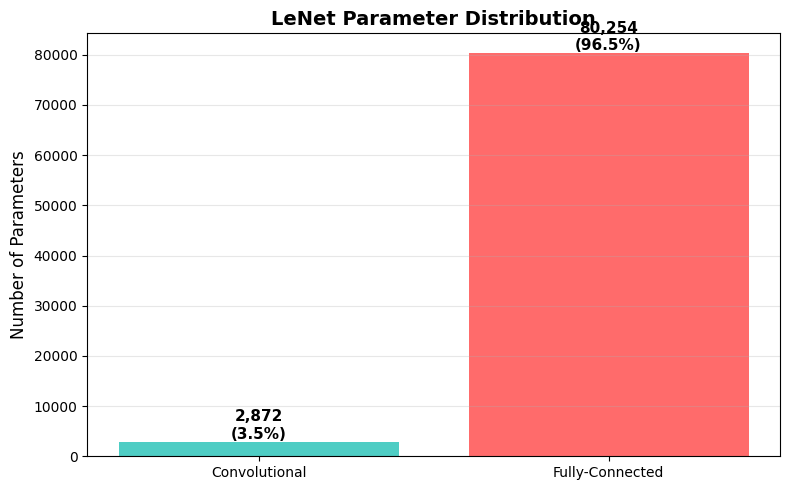

In [17]:
# Count parameters per layer type
conv_params = sum(p.numel() for name, p in model.named_parameters() if 'conv' in name)
fc_params = sum(p.numel() for name, p in model.named_parameters() if 'fc' in name)
total = conv_params + fc_params

print(f"Parameter Distribution:")
print(f"  Convolutional layers: {conv_params:>7,} ({100*conv_params/total:.1f}%)")
print(f"  Fully-connected:      {fc_params:>7,} ({100*fc_params/total:.1f}%)")
print(f"  Total:                {total:>7,}")
print(f"\n⚠️  Problem: {100*fc_params/total:.0f}% of parameters are in FC layers!")
print(f"  • FC layers have no spatial structure awareness")
print(f"  • Prone to overfitting on small datasets")
print(f"  • Don't scale well to larger images (parameters explode)")

# Visualize
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(['Convolutional', 'Fully-Connected'], 
              [conv_params, fc_params], 
              color=['#4ECDC4', '#FF6B6B'])
ax.set_ylabel('Number of Parameters', fontsize=12)
ax.set_title('LeNet Parameter Distribution', fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

# Add value labels
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(height):,}\n({100*height/total:.1f}%)',
            ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

### Limitation 6: Cannot Scale to Larger Images

**Problem:** FC layer input size depends on spatial dimensions. Larger images = parameter explosion.

Let's simulate this:

In [18]:
# Calculate FC parameters for different image sizes
def calc_fc_params(img_size):
    # After 2 pooling layers (stride 2): spatial size is img_size / 4
    # After conv2 (kernel=5, no padding): subtract 4 more pixels
    spatial_size = (img_size // 4) - 4
    if spatial_size <= 0:
        return None
    fc_input = 16 * spatial_size * spatial_size
    fc1_params = fc_input * 120  # FC1 layer
    return fc1_params

image_sizes = [32, 64, 128, 224]  # CIFAR-10, small, medium, ImageNet
fc_params_list = [calc_fc_params(size) for size in image_sizes]

print(f"FC Layer Parameters vs Image Size:")
print(f"{'Image Size':<12} {'FC1 Params':<15} {'Total Model'}")
print("-" * 45)
for size, params in zip(image_sizes, fc_params_list):
    if params:
        print(f"{size}×{size:<8} {params:>12,}   {params/1e6:>7.1f}M params")

print(f"\n⚠️  Growing 32→224 increases FC params by {fc_params_list[-1]/fc_params_list[0]:.0f}×!")
print(f"This makes LeNet impractical for high-resolution images.")

FC Layer Parameters vs Image Size:
Image Size   FC1 Params      Total Model
---------------------------------------------
32×32             30,720       0.0M params
64×64            276,480       0.3M params
128×128         1,505,280       1.5M params
224×224         5,191,680       5.2M params

⚠️  Growing 32→224 increases FC params by 169×!
This makes LeNet impractical for high-resolution images.


## 7. Summary: Why We Need Better Architectures

LeNet was revolutionary for its time, but its limitations become clear on modern tasks:

### Critical Problems

| Limitation | Impact | What's Needed |
|-----------|--------|---------------|
| **Too shallow** (2 conv layers) | Can't learn hierarchical features | **Deeper networks** |
| **Too few filters** (6, 16) | Can't capture diverse patterns | **More channels** |
| **No regularization** | Overfits easily | **Dropout + augmentation** |
| **tanh activation** | Vanishing gradients | **ReLU activation** |
| **Large FC layers** | Most params don't scale | **Global pooling or smaller FC** |
| **Fixed spatial size** | Can't handle larger images | **Adaptive architectures** |

### What AlexNet Solved

The next breakthrough, **AlexNet (2012)**, addressed these exact limitations:

1. ✅ **Deeper:** 5 conv layers instead of 2
2. ✅ **More channels:** 64→192→384→256→256 (massive capacity)
3. ✅ **ReLU activation:** 6× faster training, no vanishing gradients
4. ✅ **Dropout:** Prevents overfitting in large FC layers
5. ✅ **Data augmentation:** Random crops, flips, color jittering
6. ✅ **GPU training:** Made deep networks practical

**Result:** AlexNet achieved 15.3% error on ImageNet (1000 classes, high-resolution images), compared to 26.2% for the second-best method. This 10% improvement launched the deep learning revolution.

---

### Key Takeaway

Every limitation we identified in LeNet motivated a specific innovation in later architectures. Understanding *why* LeNet fails helps us appreciate *why* AlexNet's design choices matter.

**Next:** In the AlexNet notebook, we'll implement these solutions and see how they transform CNN performance!